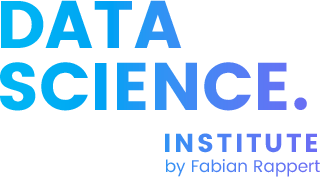

# Inhaltsverzeichnis 

- **Exceptions**
    - **Exception Handling**
    - **Built-in Exceptions Hierarchy**
    - **Exceptions werfen**
    - **Fehlermeldung auf der Konsole**


# Exceptions

Dir sind während dem Programmieren sicher schon öfters Fehlermeldungen begegnet. Die folgenden Zellen verursachen *alle* einen Fehler:

In [ ]:
print("Start.")

a = 7
b = 0
c = a / b

print("Done.")

In [ ]:
print("Start.")

print(name)

print("Done.")

In [ ]:
zahl = int("abc")

Fehler in Python nennt man auch **Exceptions** (*Ausnahmeerscheinung*). Dies sind Ereignisse, welche den Programmfluss beenden und ein Fehlerobjekt auf der Konsole ausgeben. Du siehst z.b., dass der Befehl `print("Done.")` in obigen Zellen nie ausgeführt wird. Das Programm wurde abrupt beendet! Bei der Fehlermeldung sehen wir links immer in rot stehen, welcher Art der Fehler war. Wir wollen nun versuchen, diese Fehler abzufangen.

## Exception Handling

Das Versagen eines Codeblocks und die Terminierung des Programmes kann ernsthafte Konsequenzen haben. Stelle dir vor was passieren wurde, sollte ein Banksystem oder ein anderer Dienst wegen einem Fehler im Code scheitern. Oder du hast ein Skript geschrieben, welches eine aufwendige Rechnung ausführt und bevor du die Ergebnisse speichern kannst, beendet ein Fehler das Skript!

Aus diesem Grund gibt es das `try-except`-Konstrukt für 'verdächtigen' Code. Wenn eine Wahrscheinlichkeit existiert, dass ein Codezeile das Programm abstürzen lässt, sollte man sich überlegen die Befehle in einem `try`-Block zu schreiben.

Das `try-except`-Konstrukt hat folgende Syntax:


In [ ]:
try:
    # Hier kommt der Code, den wir
    # "versuchen" wollen auszuführen
    pass

except:
    # Hier steht der Code der ausgeführt werden soll,
    # wenn ein Fehler auftaucht.
    # Hier behandeln wir normalerweise den Fehler
    pass

else:
    # Dieser Code wird ausgeführt, wenn KEIN Fehler entstanden ist.
    pass

finally:
    # Dieser Code wir IMMER ausgeührt.
    pass

In der folgenden Zelle wollen wir uns dies konkret an einem (einfachen) Beispiel anschauen.
Wir möchten zwei Zahlen dividieren und den Fehler abfangen, *falls* wir durch 0 teilen.

In [ ]:
print("Start.")

a = 7
b = 0

try:
    # Versuche die Division
    c = a / b

except:
    # Ein Fehler ist aufgetretten
    print("Error!")

else:
    # Kein Fehler ist aufgetretten
    print(f"{a} / {b} = {c}")

finally:
    print("So oder so, dieser Code wird ausgeführt.")
print("Done.")

Wenn im `try`-Teil ein Fehler verursacht wird, "springt" Python in den Teil zu `except` und führt den Code dort aus. Dadurch wird das Programm **nicht** beendet. Im obigen Beispiel wird `print("Done")` ausgeführt, *obwohl* wir davor versucht haben durch 0 zu teilen.

> <span style="color:gray"> **_AUFGABE:_** </span> Ändere im obigen Beispiel die Werte für `a` und `b`. Was ändert sich? 



Oben haben wir `except` ohne eine konkrete Exception angegeben. D.h., dass dieser Block für alle Arten von Fehlern ausgeführt wird. Es kann aber sein, dass sich unser Programm für unterschiedliche Exceptions, unterschiedliche verhalten soll. In unten stehender Zelle sehen wir eine neue Version, in welcher wir auf unterschiedliche Fehler reagieren können. 

In [ ]:
print("Start.")

a = 7
b = 0

try:
    # Versuche die Division
    c = a / b

except ImportError:
    print("ImportError!")

except NameError:
    print("NameError!")

except ArithmeticError:
    print("ArithmeticError!")

else:
    # Kein Fehler ist aufgetretten
    print(f"{a} / {b} = {c}")

print("Done.")

## Built-in Exceptions Hierarchy

Python liefert frei Haus schon verschiedene definierte Exceptions, z.b. 
- `ZeroDivisionError` beim Teilen durch 0, 
- `ArithmeticError`, wenn bei einer Rechnung ein Fehler auftaucht.
- `MemoryError`, wenn es Probleme mit dem Speicher gibt (z.b. wenn kein Speicher mehr vorhanden ist).
- `ImportError`, falls es einen Fehler beim Importieren eines Moduls gab.
- und viele mehr...

Exceptions sind hierarchisch aufgebaut. z.b. ist ein  `ZeroDivisionError` ein *Spezialfall* eines `ArithmeticError`.


Es wird **immer** die erste Exception ausgeführt, welche als erstes während der Laufzeit auftritt. Aus diesem Grund, fängt man bei den `except`-Bedingungen immer mit der spezifisten Exception an:

In [ ]:
print("Start.")

a = 7
b = 5

try:
    # Versuche die Division
    c = a / b

except ZeroDivisionError:
    # Jeder ZeroDivisionError ist ein Arithmetic Error aber nicht umgekehrt!
    print("ZeroDivsionError!")

except ArithmeticError:
    print("ArithmeticError!")

except TypeError:
    print("TypeError")

except Exception:
    print("Exception!")

except:
    print("Unknown!")

else:
    # Kein Fehler ist aufgetretten
    print(f"{a} / {b} = {c}")

print("Done.")

> <span style="color:gray"> **_AUFGABE:_** </span> Ändere im obigen Beispiel den Wert für `a` in einen String. Welcher Fehler wird verursacht?


Unten findest du die Baumstruktur der Fehlermeldung laut der [Dokumentation](https://docs.python.org/3/library/exceptions.html#exception-hierarchy).

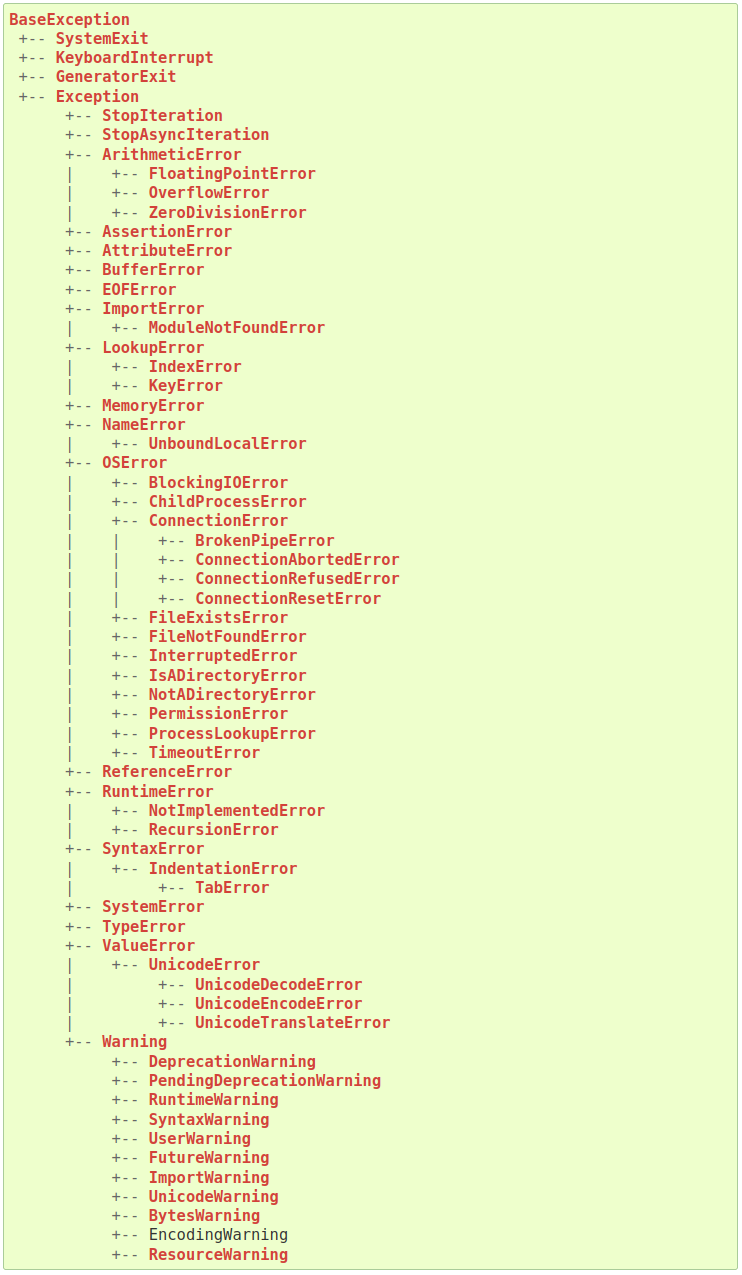

## Exceptions werfen

Wir können auch selbst Exceptions werfen, z.B. wenn spezifische Werte eingegeben sind. Dafür braucht man mit `raise` einen Exception auszuwählen. Schauen wir uns kurz ein Beispiel an.

In [ ]:
zahl = input("Bitte gib eine Zahl zwischen 1 und 10 ein.\n")

try:
    if int(zahl) > 10 or int(zahl) < 1:
        raise Exception

except ValueError:
    print("ValueError: Du hast keine Zahl angegeben!")

except Exception:
    print("Fehler: Die gewählte Zahl liegt nicht im Definitionsbereich!")

else:
    print("Danke!")

## Fehlermeldung auf der Konsole

Man muss nicht immer eine eigene Fehlermeldung schreiben, sondern man auch den ganzen Traceback auf der Konsole schreiben. 

Dafür müssen wir die Fehlermeldung als eine Variable mit `as` speichern. 

In [ ]:
try:
    5 / 0  # durch Null dividieren

except ZeroDivisionError as e:
    print("Fehlermeldung:", e)